# NiSpace workflows

The notebooks so far have built up the NiSpace pipeline step by step — `fit()`, `transform_y()`, `clean_y()`, `colocalize()`, `permute()`, `plot()`. That level of control is great when you need flexibility. But for standard analyses, NiSpace provides **workflow functions** that run the complete pipeline in a single call.

Three workflows are available:

| Function | Question answered | Null model |
|----------|-------------------|------------|
| `colocalization()` | Does this map/ Do these maps colocalize with reference maps? | Surrogate map permutation |
| `group_colocalization()` | Do brain alterations in this group colocalize with reference maps? | Group label permutation |
| `xsea()` | Does this map/ Do these maps colocalize with predefined sets of reference maps? | Surrogate map permutation |
| `group_xsea()` | Do brain alterations in this group colocalize with predefined sets of reference maps? | Group label permutation |

All workflows return a fitted `NiSpace` object. Use the `get_*` methods to retrieve results:

```python
nsp = colocalization(...)
colocs   = nsp.get_colocalizations()
p_values = nsp.get_p_values()
q_values = nsp.get_p_values(mc_method="meff")   # or any other mc_method
```

In [2]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import pandas as pd
import numpy as np

## `colocalization()` — single map

The simplest workflow: you have one group-level brain map and want to test whether they colocalize with a set of reference maps.

INFO | 04/08/26 17:26:09 | nispace.workflows: Loading integrated pet dataset as X data.


INFO | 04/08/26 17:26:09 | nispace.datasets: Loading pet maps.


INFO | 04/08/26 17:26:09 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 04/08/26 17:26:09 | nispace.datasets: Filtering maps by collection.


INFO | 04/08/26 17:26:09 | nispace.datasets: Loading data parcellated with 'Yan200'


...

INFO | 04/08/26 17:26:22 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 


INFO | 04/08/26 17:26:22 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | None      | False       | False       | 


INFO | 04/08/26 17:26:22 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | meffgalwey | False       | False       | 


INFO | 04/08/26 17:26:22 | nispace.api: Creating categorical plot for method spearman, colocalization stat rho.


INFO | 04/08/26 17:26:22 | nispace.plotting: Significance annotation: 0/29 p_uncorrected < 0.05, 0/29 p_meffgalwey < 0.05


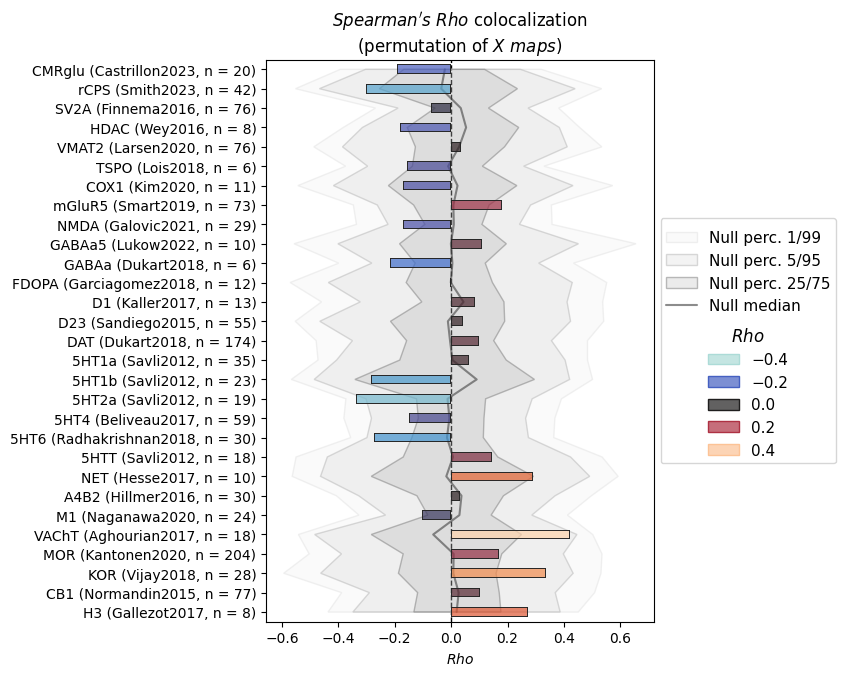

INFO | 04/08/26 17:26:22 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 


INFO | 04/08/26 17:26:22 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | None      | False       | False       | 


INFO | 04/08/26 17:26:22 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | meffgalwey | False       | False       | 


In [3]:
from nispace.workflows import colocalization
from nispace.io import load_img

pain_map = load_img("neuroquery/pain.nii.gz")

nsp = colocalization(
    y={"Pain": pain_map},  # dict key becomes the map label; can also be just the image
    x="pet",               # string shortcut: automatically fetches the PET reference dataset
    x_collection="UniqueTracers", # dataset collection to use for the PET reference dataset, optional
    parcellation="Yan200", # parcellation to use for the analysis
    colocalization_method="spearman", # colocalization method, default is "spearman"
    permute_kwargs={"p_tails": "upper"},  # directional test
    mc_method="meff", # multiple comparison correction method, default is "meff" (effective number of tests)
    n_perm=1000, # number of null runs, increase to >=10000 for final analyses
    seed=42, # random seed for reproducibility
    n_proc=4, # number of processes to use for parallelization, default is 1; set to -1 to use all available cores
    return_nispace_only=True # return only the NiSpace object, will be default in future versions
)

In [4]:
colocs   = nsp.get_colocalizations()
p_values = nsp.get_p_values()
q_values = nsp.get_p_values(mc_method="meff")

results = pd.concat([colocs, p_values, q_values], keys=["rho", "p", "q"])
results.droplevel(1).T.sort_values(by="p").head(8)

INFO | 04/08/26 17:26:22 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 


INFO | 04/08/26 17:26:22 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | None      | False       | False       | 


INFO | 04/08/26 17:26:22 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | meffgalwey | False       | False       | 


,,rho,p,q
set,map,,,
Noradrenaline/Acetylcholine,target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017,0.422783,0.073,0.602089
Opioids/Endocannabinoids,target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018,0.335397,0.103,0.733256
Histamine,target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017,0.273213,0.164,0.886693
Glutamate,target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019,0.180214,0.172,0.899194
Noradrenaline/Acetylcholine,target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017,0.288889,0.255,0.972088
Opioids/Endocannabinoids,target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020,0.171576,0.259,0.973856
Serotonin,target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012,0.145715,0.294,0.985482
Dopamine,target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018,0.097589,0.332,0.992590


INFO | 04/08/26 17:26:22 | nispace.api: *** NiSpace.plot() - Plot colocalization results. ***


INFO | 04/08/26 17:26:22 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | None      | False       | False       | 


INFO | 04/08/26 17:26:22 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 


INFO | 04/08/26 17:26:22 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | None      | False       | False       | 


INFO | 04/08/26 17:26:22 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | meffgalwey | False       | False       | 


INFO | 04/08/26 17:26:22 | nispace.api: Creating categorical plot for method spearman, colocalization stat rho.


INFO | 04/08/26 17:26:22 | nispace.plotting: Significance annotation: 0/29 p_uncorrected < 0.05, 0/29 p_meffgalwey < 0.05


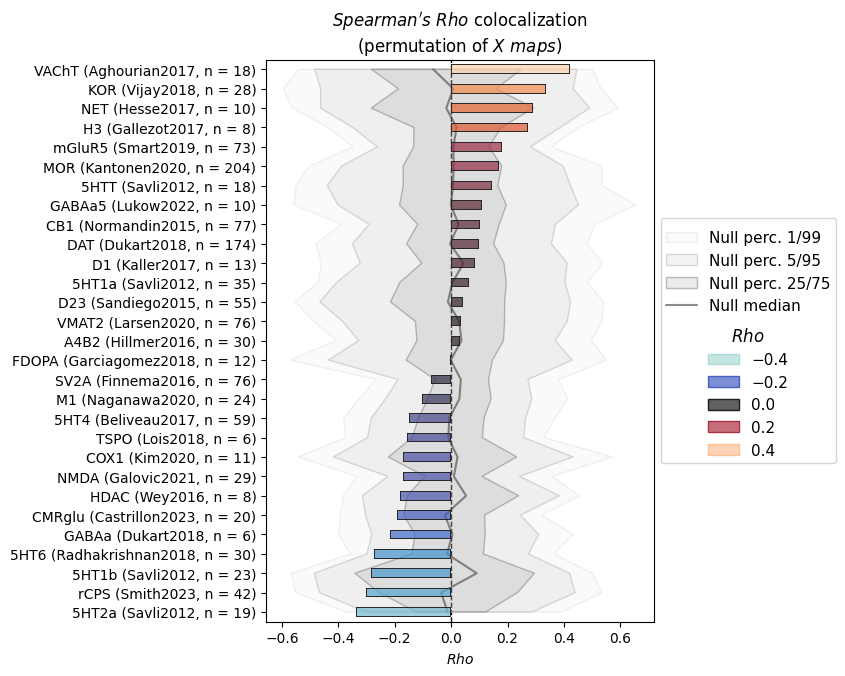

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x348e83340>)

In [5]:
# the nsp_object is a fully fitted NiSpace object — you can use all methods on it
nsp.plot(sort_by="coloc")

## `colocalization()` — multiple maps

You have **multiple** brain maps and want to test whether they colocalize with a set of reference maps.  
Here, we have an important parameter, `pooled_p`, that determines if p values are calculated for the average of colocalizations acoss your input maps or if one p value is calculated for each of the input maps.

Examples:
- `pooled_p=True`: Multiple alterations maps from the same disorder (e.g., subject-level or group-level). "Do  these 5 meta-analytic maps comparing depression to controls colocalize consistently with X?" 
- `pooled_p=False`: "How does each of these ENGIMA maps for different disorders correlate spatially with nuclear imaging maps?"

INFO | 04/08/26 17:26:22 | nispace.datasets: Loading enigmathick maps.


INFO | 04/08/26 17:26:22 | nispace.datasets: Loading data parcellated with 'DesikanKilliany'


ENIGMA: 22 disorder maps x 68 parcels
Disorders: ['dx-mdd_age-adult_pub-schmaal2017', 'dx-mdd_age-adolescent_pub-schmaal2017', 'dx-adhd_age-allages_pub-hoogman2019', 'dx-adhd_age-adult_pub-hoogman2019'] ...
INFO | 04/08/26 17:26:22 | nispace.workflows: Loading integrated pet dataset as X data.


INFO | 04/08/26 17:26:22 | nispace.datasets: Loading pet maps.


INFO | 04/08/26 17:26:22 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


...

INFO | 04/08/26 17:26:27 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 


INFO | 04/08/26 17:26:27 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | None      | False       | False       | 


INFO | 04/08/26 17:26:27 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | meffgalwey | False       | False       | 


INFO | 04/08/26 17:26:27 | nispace.api: Creating categorical plot for method spearman, colocalization stat rho.


INFO | 04/08/26 17:26:27 | nispace.plotting: Significance annotation: 0/29 p_uncorrected < 0.05, 0/29 p_meffgalwey < 0.05


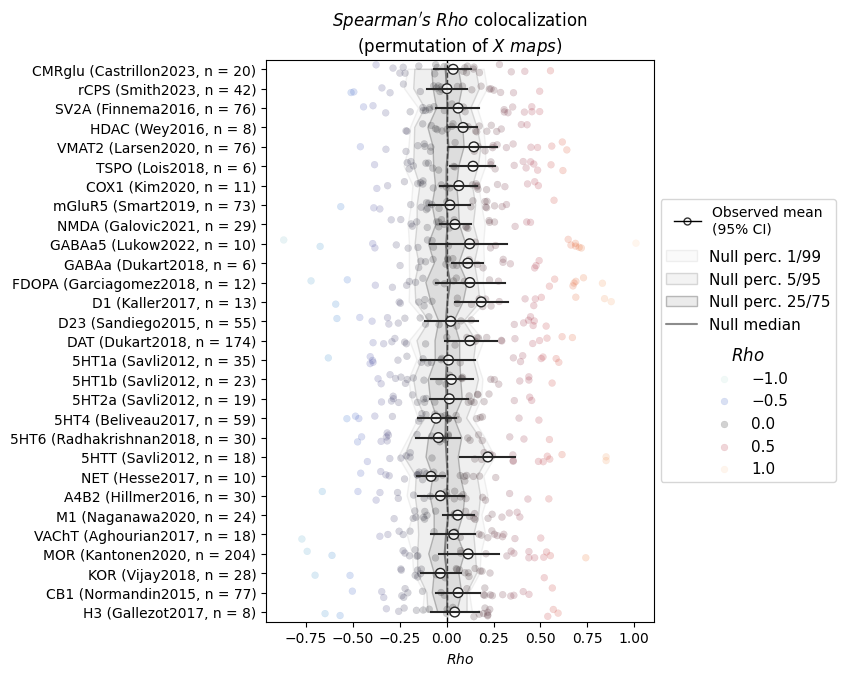

INFO | 04/08/26 17:26:27 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 


INFO | 04/08/26 17:26:27 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | None      | False       | False       | 


INFO | 04/08/26 17:26:27 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | meffgalwey | False       | False       | 


INFO | 04/08/26 17:26:27 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | None      | False       | False       | 



pooled_p='mean' → p-values shape: (1, 29)
  1 pooled row × 29 receptor columns


In [6]:
from nispace.datasets import fetch_reference

# ENIGMA cortical thickness effect sizes — 22 psychiatric disorders, DesikanKilliany parcellation
# This is a natural multi-map case: we have separate effect size maps per disorder
enigma = fetch_reference("enigmathick", parcellation="DesikanKilliany", print_references=False)
print(f"ENIGMA: {enigma.shape[0]} disorder maps x {enigma.shape[1]} parcels")
print("Disorders:", list(enigma.index[:4]), "...")

# --- pooled_p=False (default): one p-value per disorder × receptor pair ---
# Use case: "how does each disorder's cortical thinning relate to each receptor?"
nsp_multi = colocalization(
    y=enigma,
    x="pet",
    x_collection="UniqueTracers",
    parcellation="DesikanKilliany",
    colocalization_method="spearman",
    pooled_p=False,     # one p per (Y map, X map) pair — default
    mc_method="meff",
    n_perm=1000,        # increase to >=10000 for final analyses
    seed=42, n_proc=4,
    plot=False, # not correctly implemented currently
    return_nispace_only=True
)
p_per_map = nsp_multi.get_p_values()
print(f"\npooled_p=False  → p-values shape: {p_per_map.shape}")
print(f"  {enigma.shape[0]} disorder rows × {p_per_map.shape[1]} receptor columns")

# --- pooled_p="mean": one pooled p-value per X map across all Y maps ---
# Use case: "do these disorders collectively and consistently colocalize with each receptor?"
nsp_pooled = colocalization(
    y=enigma,
    x="pet",
    x_collection="UniqueTracers",
    parcellation="DesikanKilliany",
    colocalization_method="spearman",
    pooled_p="mean",    # average colocs across Y maps → one p per X map
    mc_method="meff",
    n_perm=1000,
    seed=42, n_proc=4,
    plot=True,
    return_nispace_only=True
)
p_pooled = nsp_pooled.get_p_values()
print(f"\npooled_p='mean' → p-values shape: {p_pooled.shape}")
print(f"  1 pooled row × {p_pooled.shape[1]} receptor columns")

## `group_colocalization()` — patient vs. control

The group comparison workflow handles the full pipeline for individual subject data: covariate regression, effect size computation, colocalization, and group label permutation.

The `design` argument is a DataFrame with one row per subject. The column `"groups"` is required; any other columns are treated as covariates to regress out. A `"site"` column triggers ComBat harmonization if `combat=True`.

We use the anorexia nervosa example dataset here.

> **Note:** This dataset is **simulated** and not intended for scientific use — it exists purely for demonstration purposes.

This workflow employs group label permutation to generate null maps (as compared to spatial null models). This is a very elegant approach for group comparisons in spatial correlation analyses because general spatial patterns will naturally be conserved in the permuted alteration images, without relying on a null model's ability to capture said spatial patterns.

INFO | 04/08/26 17:26:27 | nispace.datasets: Loading example dataset: 'anorexianervosa', parcellated with: Yan200.


INFO | 04/08/26 17:26:27 | nispace.workflows: Loading integrated pet dataset as X data.


INFO | 04/08/26 17:26:27 | nispace.datasets: Loading pet maps.


INFO | 04/08/26 17:26:27 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 04/08/26 17:26:27 | nispace.datasets: Filtering maps by collection.


...

INFO | 04/08/26 17:26:28 | nispace.workflows: DataFrame provided for design. Expecting 'groups' and, if paired==True, 'subjects' columns.


INFO | 04/08/26 17:26:28 | nispace.workflows: Design matrix of shape (100, 3). Assuming 100 subjects/maps.


INFO | 04/08/26 17:26:28 | nispace.api: *** NiSpace.clean_y() - Y covariate regression. ***


INFO | 04/08/26 17:26:28 | nispace.api: Performing covariate regression between maps/subjects (e.g., age, sex, site).


INFO | 04/08/26 17:26:28 | nispace.core.clean_y: Detected categorical covariates: none; continuous: ['age', 'sex'].


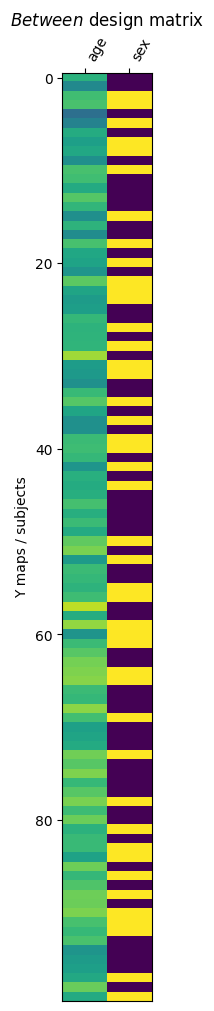

INFO | 04/08/26 17:26:28 | nispace.core.clean_y: Protecting 1 variable(s) during regression: ['groups_HC'].


INFO | 04/08/26 17:26:28 | nispace.core.clean_y: Regressing 2 between covariate(s) from Y, protecting 1 variable(s).


Regressing 2 between covariate(s) from Y (4 proc): 100%|██████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 58.02it/s]

INFO | 04/08/26 17:26:32 | nispace.api: *** NiSpace.transform_y() - Y transformation and comparison. ***


INFO | 04/08/26 17:26:32 | nispace.api: Groups/sessions vector provided, ensuring dummy-coding.


...

INFO | 04/08/26 17:26:33 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:33 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | False | None      | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:33 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | False | meffgalwey | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:33 | nispace.api: Creating categorical plot for method spearman, colocalization stat rho.


INFO | 04/08/26 17:26:33 | nispace.plotting: Significance annotation: 13/29 p_uncorrected < 0.05, 6/29 p_meffgalwey < 0.05


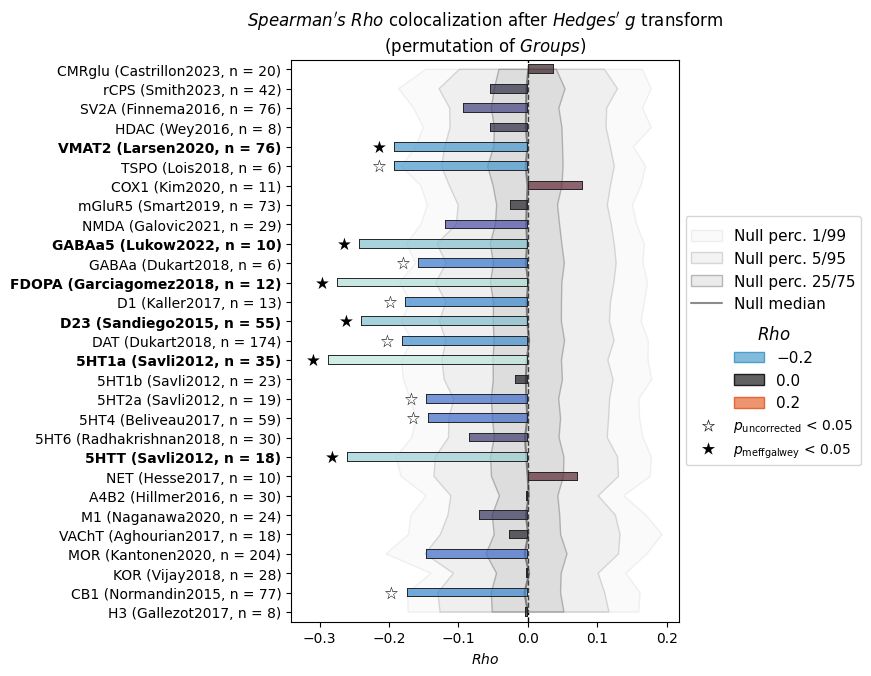

INFO | 04/08/26 17:26:33 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:33 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | False | None      | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:33 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | False | meffgalwey | False       | hedges(a,b) | 


In [7]:
from nispace.workflows import group_colocalization
from nispace.datasets import fetch_example

# load the anorexia nervosa example data
an_data = fetch_example("anorexianervosa", parcellation="Yan200")

# extract group labels
groups = an_data.index.str.extract(r'(AN|HC)$')[0].values

# generate synthetic covariates
rng = np.random.default_rng(42)
age = np.concatenate([rng.normal(25, 5, 50), rng.normal(30, 5, 50)])
sex = rng.integers(0, 2, 100)

# design matrix: groups column is mandatory, others are covariates
design = pd.DataFrame({
    "groups": groups,
    "age": age,
    "sex": sex
}, index=an_data.index)

nsp_gc = group_colocalization(
    y=an_data,
    design=design,
    x="pet",
    x_collection="UniqueTracers",
    parcellation="Yan200",
    comparison_method="hedges(a,b)",
    colocalization_method="spearman",
    n_perm=1000,
    seed=42,
    n_proc=4,
    return_nispace_only=True
)

In [8]:
colocs_gc = nsp_gc.get_colocalizations()
p_gc      = nsp_gc.get_p_values()
q_gc      = nsp_gc.get_corrected_p_values() # short cut for get_p_values(mc_method="meff")

gc_results = pd.concat([colocs_gc, p_gc, q_gc], keys=["rho", "p", "q"])
gc_results.droplevel(1).T.sort_values(by="p").head(8)

INFO | 04/08/26 17:26:33 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:33 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | False | None      | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:33 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | False | meffgalwey | False       | hedges(a,b) | 


rho      p  \
set       map                                                                   
Serotonin target-5HT1a_tracer-way100635_n-35_dx-hc_pub-sa... -0.288109  0.001   
          target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   -0.261052  0.001   
Dopamine  target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-g... -0.275181  0.002   
          target-D23_tracer-flb457_n-55_dx-hc_pub-sandieg... -0.239887  0.004   
General   target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020 -0.193007  0.004   
GABA      target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lu... -0.242692  0.004   
Dopamine  target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018 -0.180989  0.012   
          target-D1_tracer-sch23390_n-13_dx-hc_pub-kaller... -0.176689  0.016   

                                                                     q  
set       map                                                           
Serotonin target-5HT1a_tracer-way100635_n-35_dx-hc_pub-sa...  0.012089  
          target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012    0.012089  
Dopamine  target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-g...  0.024045  
          target-D23_tracer-flb457_n-55_dx-hc_pub-sandieg...  0.047558  
General   target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020  0.047558  
GABA      target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lu...  0.047558  
Dopamine  target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018  0.136505  
          target-D1_tracer-sch23390_n-13_dx-hc_pub-kaller...  0.178059

INFO | 04/08/26 17:26:33 | nispace.api: *** NiSpace.plot() - Plot colocalization results. ***


INFO | 04/08/26 17:26:33 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | False | None      | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:33 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:33 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | False | None      | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:33 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | False | meffgalwey | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:33 | nispace.api: Creating categorical plot for method spearman, colocalization stat rho.


INFO | 04/08/26 17:26:33 | nispace.plotting: Significance annotation: 13/29 p_uncorrected < 0.05, 6/29 p_meffgalwey < 0.05


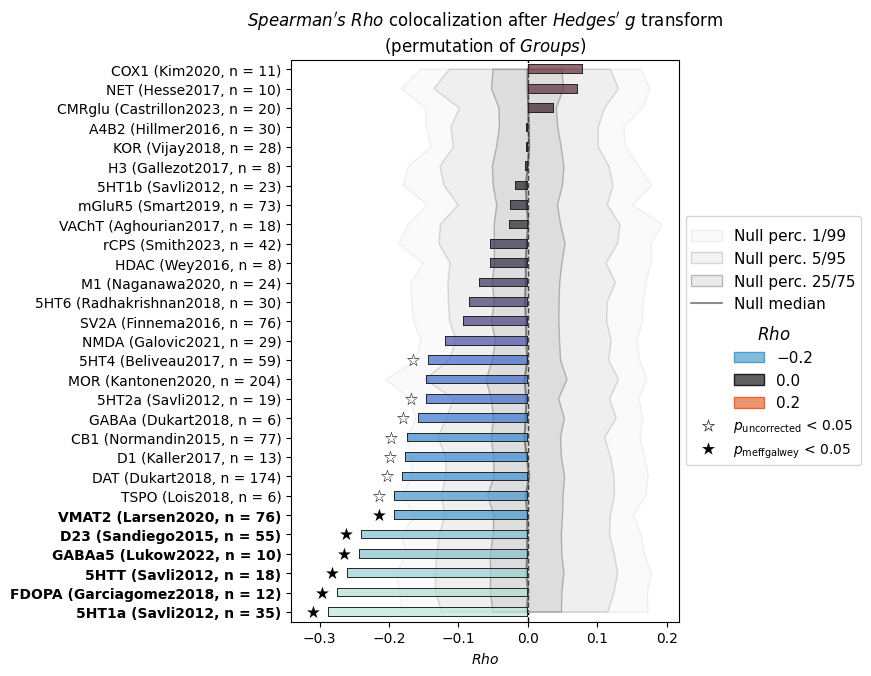

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization after $Hedges'\\ g$ transform\n(permutation of $Groups$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x383145be0>)

In [9]:
nsp_gc.plot(sort_by="coloc")

INFO | 04/08/26 17:26:33 | nispace.api: *** NiSpace.plot_brain() ***


INFO | 04/08/26 17:26:33 | nispace.api: Plotting Y data (Y_transform='hedges(a,b)').


INFO | 04/08/26 17:26:33 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| hedges(a,b) | 


WARNING | 04/08/26 17:26:33 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 04/08/26 17:26:33 | nispace.plotting: brainplot: threshold='auto' → 0.0025388153735548258


INFO | 04/08/26 17:26:33 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.


INFO | 04/08/26 17:26:34 | nispace.core.parcellation: Parcellation 'Yan200': active space set to 'MNI152NLin2009cAsym' (was 'fsLR').


INFO | 04/08/26 17:26:34 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


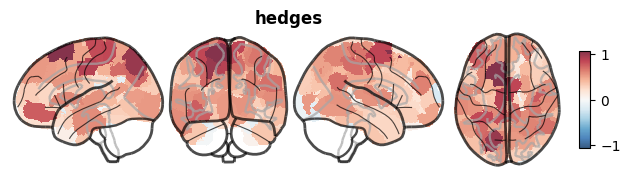

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

In [10]:
# effect size map on the brain
nsp_gc.plot_brain(data="Y", symmetric_cmap=True)

## `xsea()` — X-Set Enrichment Analysis

XSEA tests whether the average colocalization between your input map and a *set* of reference maps is higher than expected by chance. This is useful when you have reference maps organized into biologically meaningful groups (e.g., gene expression grouped by cell type).

Note that, as above, you can pass more than one map here to the `y` parameter. The `pooled_p` here equally determines if you get one p value per input map or one p value across all input maps.

We'll cover XSEA in much more detail in [Notebook 10](intro10_xsea.ipynb). Here's a minimal example:

INFO | 04/08/26 17:26:37 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| hedges(a,b) | 


INFO | 04/08/26 17:26:37 | nispace.workflows: Loading integrated mrna dataset as X data.


INFO | 04/08/26 17:26:37 | nispace.datasets: Loading mrna maps.


INFO | 04/08/26 17:26:37 | nispace.datasets: Loading integrated collection 'CellTypesSilettiSuperclusters' for dataset 'mrna'.


INFO | 04/08/26 17:26:37 | nispace.datasets: Filtering maps by collection.


...

INFO | 04/08/26 17:26:41 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 


INFO | 04/08/26 17:26:41 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | None      | False       | False       | 


INFO | 04/08/26 17:26:41 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | meffgalwey | False       | False       | 


INFO | 04/08/26 17:26:41 | nispace.api: Creating categorical plot for method spearman, colocalization stat rho.


INFO | 04/08/26 17:26:41 | nispace.plotting: Significance annotation: 0/29 p_uncorrected < 0.05, 0/29 p_meffgalwey < 0.05


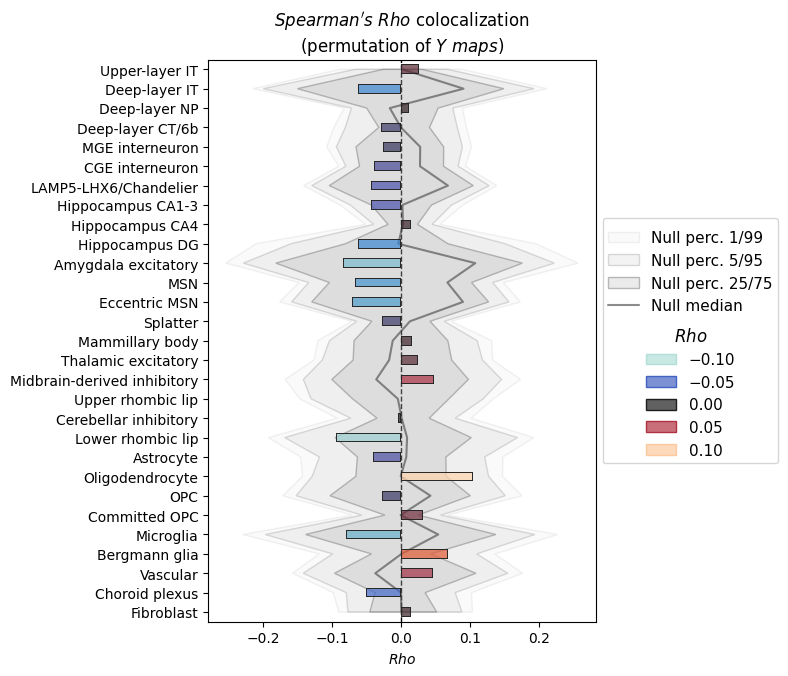

INFO | 04/08/26 17:26:41 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 


INFO | 04/08/26 17:26:41 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | None      | False       | False       | 


INFO | 04/08/26 17:26:41 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | meffgalwey | False       | False       | 


In [11]:
from nispace.workflows import xsea
from nispace.datasets import fetch_reference

# use the anorexia nervosa Hedges' g map we computed above
hedges_g = nsp_gc.get_y()

# test against mRNA gene expression sets (cell type markers)
nsp_xsea = xsea(
    y=hedges_g,
    x="mrna",          # mRNA gene expression reference
    x_collection="CellTypesSilettiSuperclusters",  # predefined cell type sets
    parcellation="Yan200",
    colocalization_method="spearman",
    n_perm=1000,
    seed=42,
    n_proc=4,
    return_nispace_only=True
)

INFO | 04/08/26 17:26:41 | nispace.api: *** NiSpace.plot() - Plot colocalization results. ***


INFO | 04/08/26 17:26:41 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | None      | False       | False       | 


INFO | 04/08/26 17:26:41 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 


INFO | 04/08/26 17:26:41 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | None      | False       | False       | 


INFO | 04/08/26 17:26:41 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | meffgalwey | False       | False       | 


INFO | 04/08/26 17:26:41 | nispace.api: Creating categorical plot for method spearman, colocalization stat rho.


INFO | 04/08/26 17:26:41 | nispace.plotting: Significance annotation: 0/29 p_uncorrected < 0.05, 0/29 p_meffgalwey < 0.05


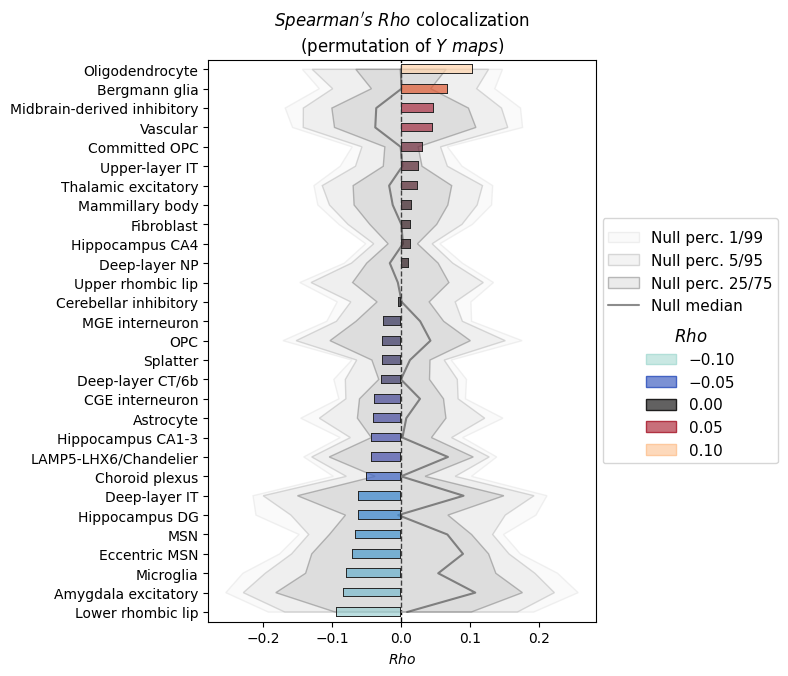

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $Y\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x3946dc160>)

In [12]:
nsp_xsea.plot(sort_by="coloc")

## `group_xsea()` — group comparison with set enrichment

`group_xsea()` combines the group comparison design of `group_colocalization()` with the set-level aggregation of `xsea()`. It is the right workflow when you have individual subject data and want to ask whether the effect size map of a group difference aligns with specific biological systems — gene expression cell types, neurotransmitter systems, etc.

Under the hood it is exactly `group_colocalization()` with XSEA activated: group labels are permuted to generate null effect size maps, and those null maps are then used to build the null distribution for set-level colocalizations.

We use the same anorexia nervosa data and design matrix from the previous section.

> **Note:** The anorexia nervosa dataset is **simulated** and not intended for scientific use.

INFO | 04/08/26 17:26:41 | nispace.workflows: Loading integrated mrna dataset as X data.


INFO | 04/08/26 17:26:41 | nispace.datasets: Loading mrna maps.


INFO | 04/08/26 17:26:41 | nispace.datasets: Loading integrated collection 'CellTypesSilettiSuperclusters' for dataset 'mrna'.


INFO | 04/08/26 17:26:41 | nispace.datasets: Filtering maps by collection.


INFO | 04/08/26 17:26:42 | nispace.datasets: Loading data parcellated with 'Yan200'


...

INFO | 04/08/26 17:26:43 | nispace.workflows: DataFrame provided for design. Expecting 'groups' and, if paired==True, 'subjects' columns.


INFO | 04/08/26 17:26:43 | nispace.workflows: Design matrix of shape (100, 3). Assuming 100 subjects/maps.


INFO | 04/08/26 17:26:43 | nispace.api: *** NiSpace.clean_y() - Y covariate regression. ***


INFO | 04/08/26 17:26:43 | nispace.api: Performing covariate regression between maps/subjects (e.g., age, sex, site).


INFO | 04/08/26 17:26:43 | nispace.core.clean_y: Detected categorical covariates: none; continuous: ['age', 'sex'].


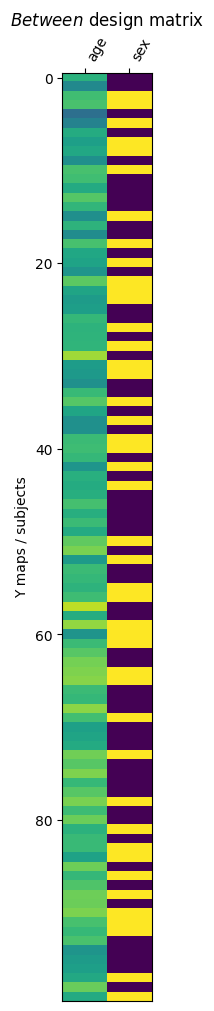

INFO | 04/08/26 17:26:43 | nispace.core.clean_y: Protecting 1 variable(s) during regression: ['groups_HC'].


INFO | 04/08/26 17:26:43 | nispace.core.clean_y: Regressing 2 between covariate(s) from Y, protecting 1 variable(s).


Regressing 2 between covariate(s) from Y (4 proc): 100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 4970.08it/s]

INFO | 04/08/26 17:26:43 | nispace.api: *** NiSpace.transform_y() - Y transformation and comparison. ***


INFO | 04/08/26 17:26:43 | nispace.api: Groups/sessions vector provided, ensuring dummy-coding.


...

INFO | 04/08/26 17:26:44 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:44 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | True | None      | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:44 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | True | meffgalwey | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:44 | nispace.api: Creating categorical plot for method spearman, colocalization stat rho.


INFO | 04/08/26 17:26:44 | nispace.plotting: Significance annotation: 3/29 p_uncorrected < 0.05, 0/29 p_meffgalwey < 0.05


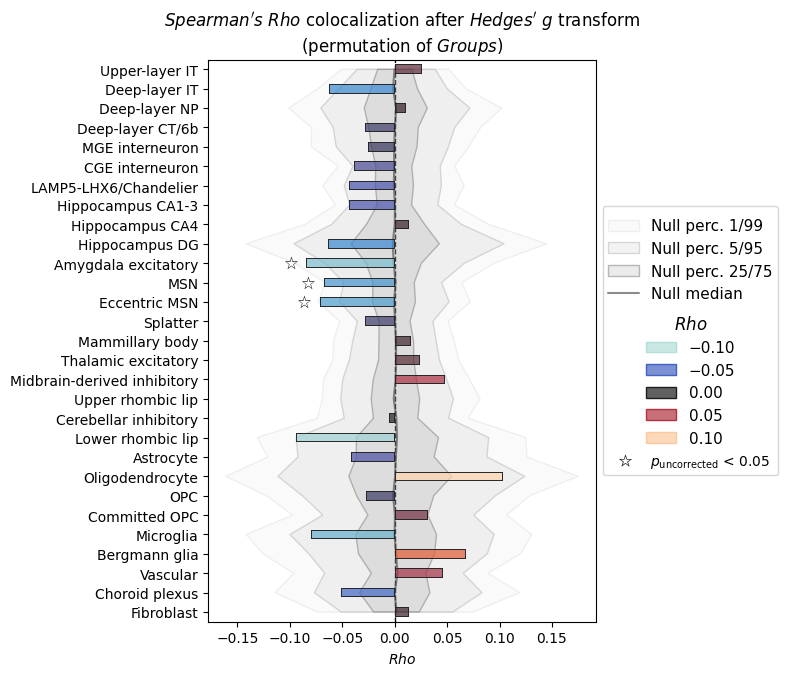

INFO | 04/08/26 17:26:45 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:45 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | True | None      | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:45 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | True | meffgalwey | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:45 | nispace.api: *** NiSpace.plot() - Plot colocalization results. ***


INFO | 04/08/26 17:26:45 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | True | None      | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:45 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:45 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | True | None      | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:45 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | groups       | True | meffgalwey | False       | hedges(a,b) | 


INFO | 04/08/26 17:26:45 | nispace.api: Creating categorical plot for method spearman, colocalization stat rho.


INFO | 04/08/26 17:26:45 | nispace.plotting: Significance annotation: 3/29 p_uncorrected < 0.05, 0/29 p_meffgalwey < 0.05


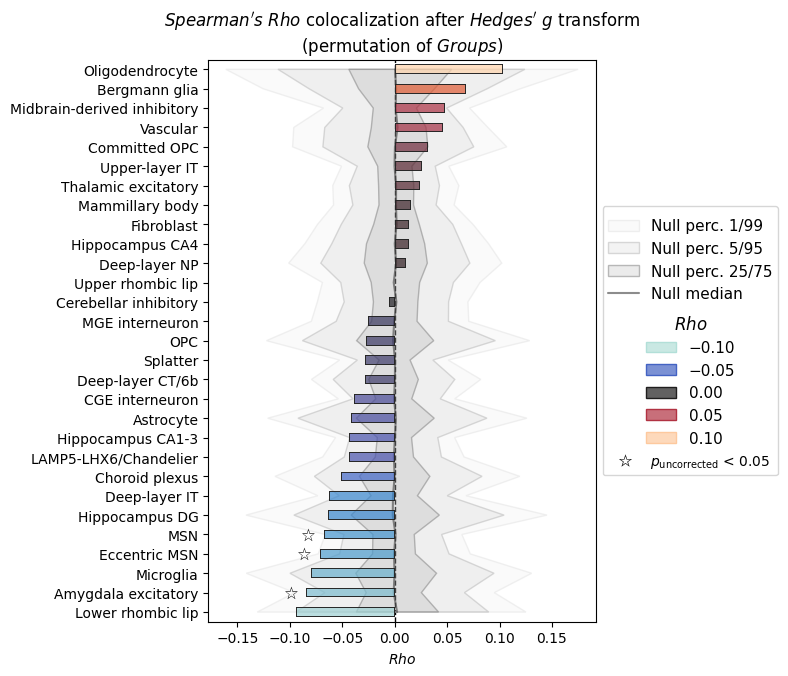

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization after $Hedges'\\ g$ transform\n(permutation of $Groups$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x3f5389be0>)

In [13]:
from nispace.workflows import group_xsea

nsp_gxsea = group_xsea(
    y=an_data,
    design=design,
    x="mrna",
    x_collection="CellTypesSilettiSuperclusters",
    parcellation="Yan200",
    comparison_method="hedges(a,b)",
    colocalization_method="spearman",
    mc_method="meff",
    n_perm=1000,
    seed=42, n_proc=4,
    return_nispace_only=True
)
nsp_gxsea.plot(sort_by="coloc")

## When to use workflows vs. the object API

| Situation | Recommended approach |
|-----------|---------------------|
| Quick analysis, standard pipeline | Workflow function |
| Need full control over each step | Object API (`NiSpace` class) |
| Custom preprocessing sequence | Object API |
| Running the same analysis on many maps | Object API (reuse the fitted object) |
| Embedding in a larger pipeline | Object API |
| Teaching/demonstration | Workflow (less boilerplate) |

The two approaches are not exclusive. You can start with a workflow, inspect the returned `nsp` object, and then call additional methods on it.

## Summary

Four workflow functions, all returning a fitted `NiSpace` object with `return_nispace_only=True`:

| Function | Input Y | Reference X | Null model |
|----------|---------|-------------|------------|
| `colocalization()` | Group-level map(s) | Any | Surrogate map permutation |
| `group_colocalization()` | Individual subjects + design | Any | Group label permutation |
| `xsea()` | Group-level map(s) | Set-structured | Surrogate map permutation |
| `group_xsea()` | Individual subjects + design | Set-structured | Group label permutation |

The `pooled_p` parameter controls how p-values are computed when multiple Y maps are passed:
- `pooled_p=False` — one p-value per (Y map × X map) pair (default)
- `pooled_p="mean"` — average colocalizations across Y maps first, then compute one p per X map
- `pooled_p="auto"` — `False` for a single Y map, `"mean"` otherwise

```python
nsp = colocalization(y, x="pet", x_collection=None, parcellation="Yan200",
                     colocalization_method="spearman", mc_method="meff",
                     pooled_p=False, n_perm=10000, seed=None, n_proc=1, return_nispace_only=True)

nsp = group_colocalization(y, design, x="pet", comparison_method="hedges(a,b)",
                           parcellation="Yan200", colocalization_method="spearman",
                           mc_method="meff", n_perm=10000,
                           seed=None, n_proc=1, return_nispace_only=True)

nsp = xsea(y, x="mrna", x_collection=None, parcellation="Yan200",
           colocalization_method="spearman", mc_method="meff",
           pooled_p=False, n_perm=10000, seed=None, n_proc=1, return_nispace_only=True)

nsp = group_xsea(y, design, x="mrna", x_collection=None,
                 comparison_method="hedges(a,b)", parcellation="Yan200",
                 colocalization_method="spearman", mc_method="meff",
                 n_perm=10000, seed=None, n_proc=1, return_nispace_only=True)

# retrieve results
colocs   = nsp.get_colocalizations()
p_values = nsp.get_p_values()
q_values = nsp.get_p_values(mc_method="meff")
```

Next: [Notebook 10](intro10_xsea.ipynb) dives deep into X-Set Enrichment Analysis.